In [1]:
# load vgg model
from keras.applications.vgg16 import VGG16
# load the model
model = VGG16()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [2]:
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

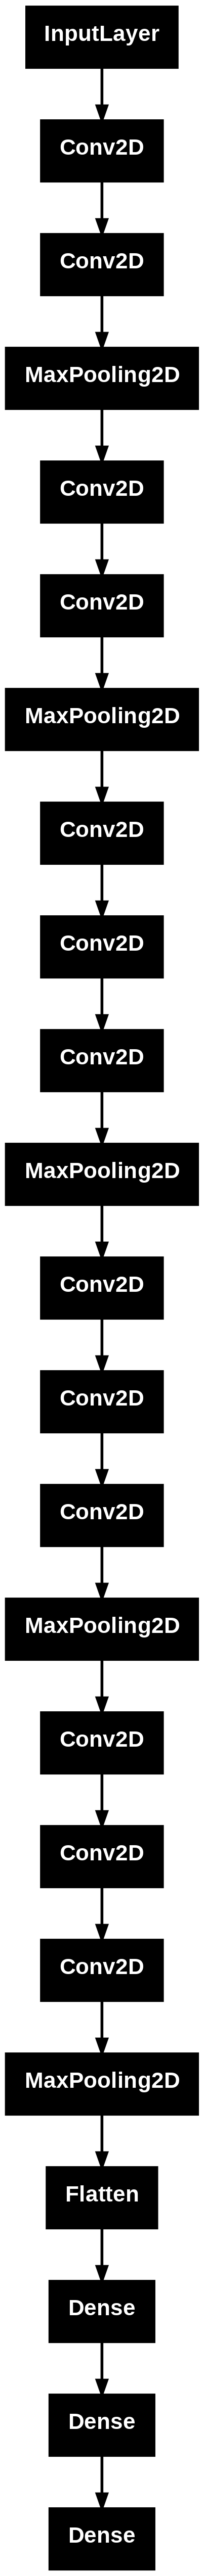

In [3]:
## Visualize the model
from keras.utils import plot_model
plot_model(model)

In [5]:
# summarize the filter shape
for i in range(len(model.layers)):
  if 'conv' not in model.layers[i].name:
    continue
  # get filter weights
  filters, biases = model.layers[i].get_weights()
  print("Layer numbers:",i,model.layers[i].name,filters.shape)

Layer numbers: 1 block1_conv1 (3, 3, 3, 64)
Layer numbers: 2 block1_conv2 (3, 3, 64, 64)
Layer numbers: 4 block2_conv1 (3, 3, 64, 128)
Layer numbers: 5 block2_conv2 (3, 3, 128, 128)
Layer numbers: 7 block3_conv1 (3, 3, 128, 256)
Layer numbers: 8 block3_conv2 (3, 3, 256, 256)
Layer numbers: 9 block3_conv3 (3, 3, 256, 256)
Layer numbers: 11 block4_conv1 (3, 3, 256, 512)
Layer numbers: 12 block4_conv2 (3, 3, 512, 512)
Layer numbers: 13 block4_conv3 (3, 3, 512, 512)
Layer numbers: 15 block5_conv1 (3, 3, 512, 512)
Layer numbers: 16 block5_conv2 (3, 3, 512, 512)
Layer numbers: 17 block5_conv3 (3, 3, 512, 512)


In [6]:
# retrieve weights from the second hidden layers
filters , biases = model.layers[1].get_weights()

In [9]:
# Normalize the value between 0 - 1
f_min , f_max = filters.min() , filters.max()
filters = (filters - f_min) / (f_max - f_min)

<function matplotlib.pyplot.show(close=None, block=None)>

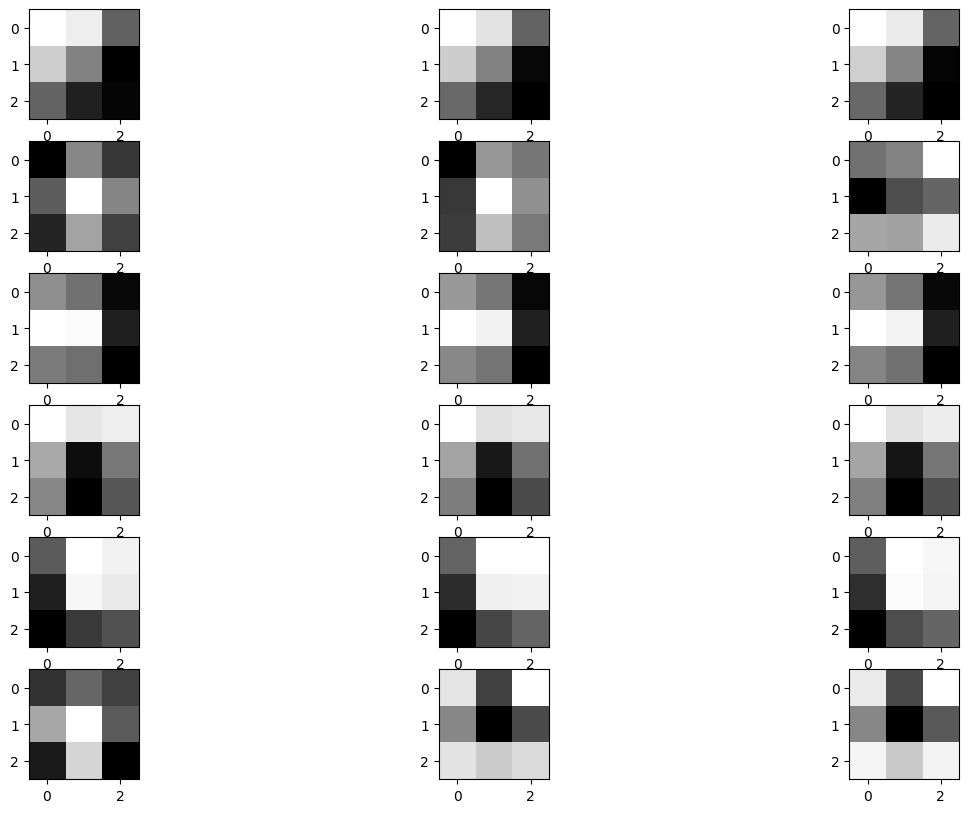

In [15]:
import matplotlib.pyplot as plt
n_filters = 6
ix=1
fig = plt.figure(figsize=(15,10))
for i in range(n_filters):
  # get the filters
  f = filters[:,:,:,i]
  for j in range(3):
    plt.subplot(n_filters,3,ix)
    plt.imshow(f[:,:,j],cmap='gray')
    ix+=1
plt.show

In [19]:
# redefine model to output right after the first hidden layer
from keras.models import Model
model = Model(inputs=model.inputs, outputs=model.layers[1].output)

In [34]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
from keras.applications.vgg16 import preprocess_input

image = load_img("/content/ChatGPT Image Jul 26, 2026, 12_02_00 AM (1).png",target_size=(224,224))

# Convert image into array
image = img_to_array(image)

# expand dimension so that it represents a single 'sample'
image = np.expand_dims(image, axis=0)

image = preprocess_input(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


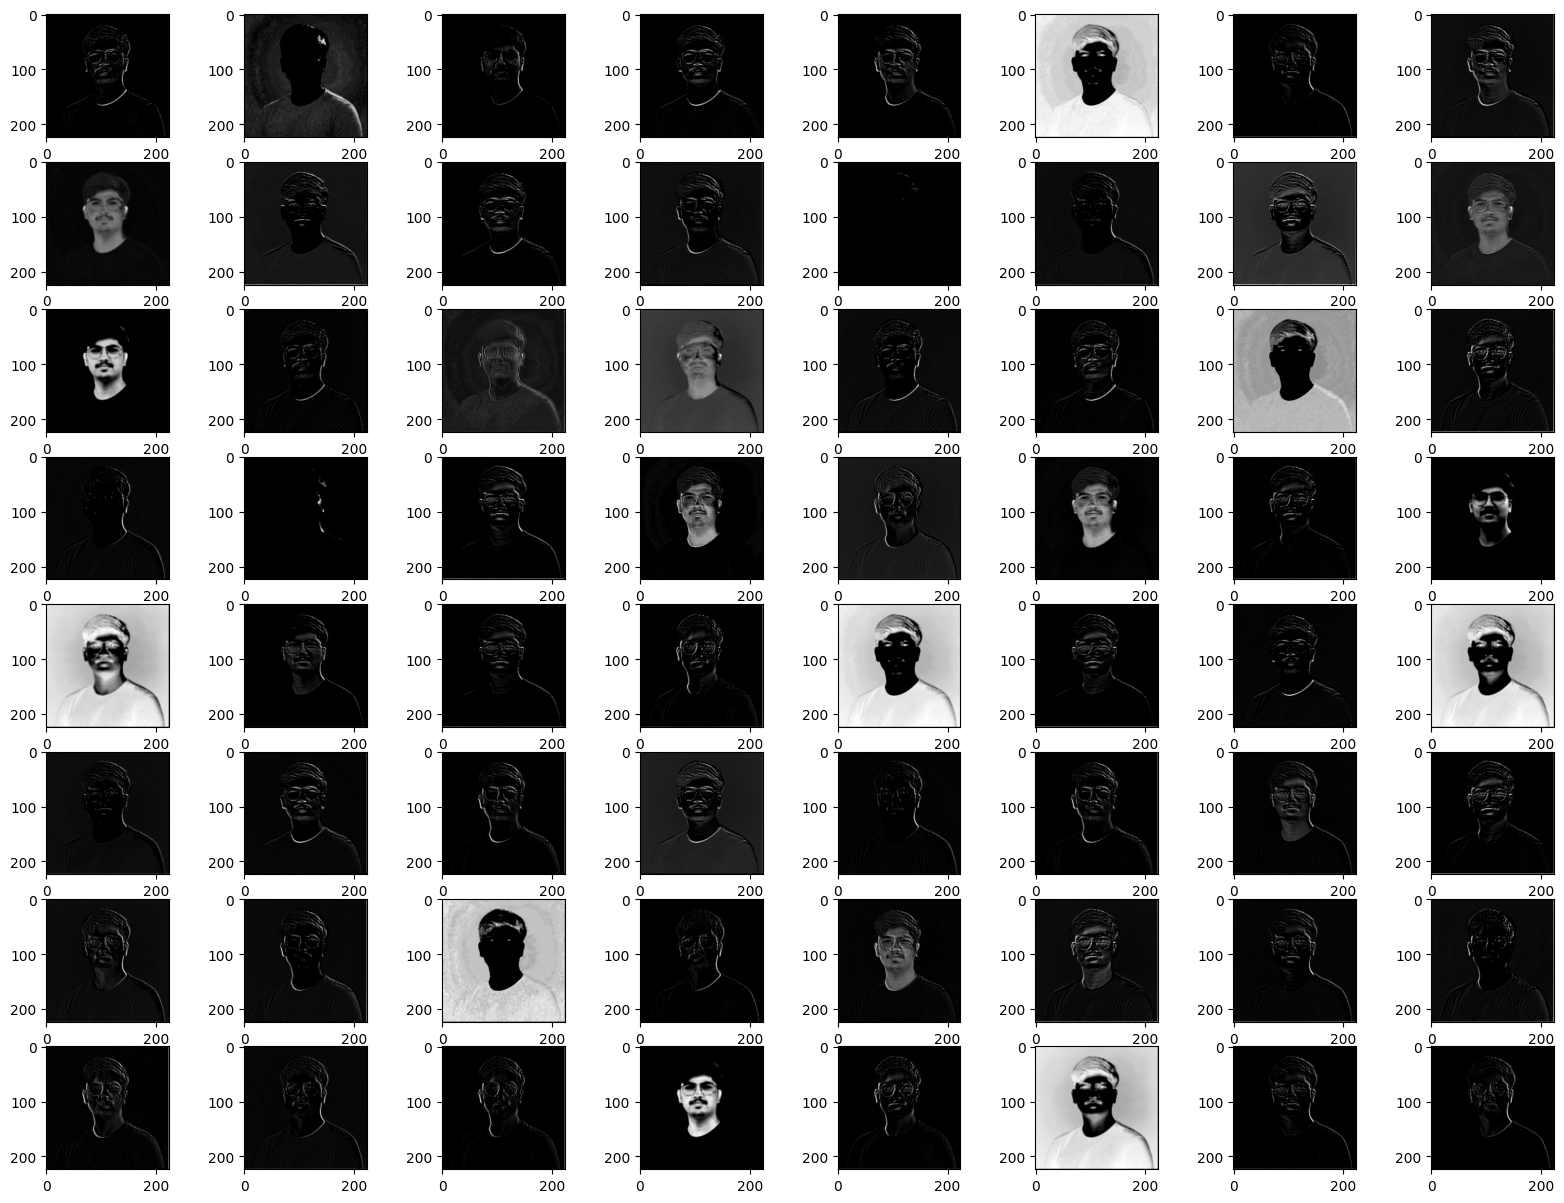

In [36]:
# Calculating feature map
features = model.predict(image)

fig = plt.figure(figsize=(20,15))
for i in range(1,features.shape[3]+1):

  plt.subplot(8,8,i)
  plt.imshow(features[0,:,:,i-1] , cmap='gray')
plt.show()

In [37]:
model2 = VGG16()

In [38]:
layer_index = [0,1,6,9,14,17]
outputs = [model2.layers[i].output for i in layer_index]

model3 = Model( inputs= model2.inputs, outputs = outputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


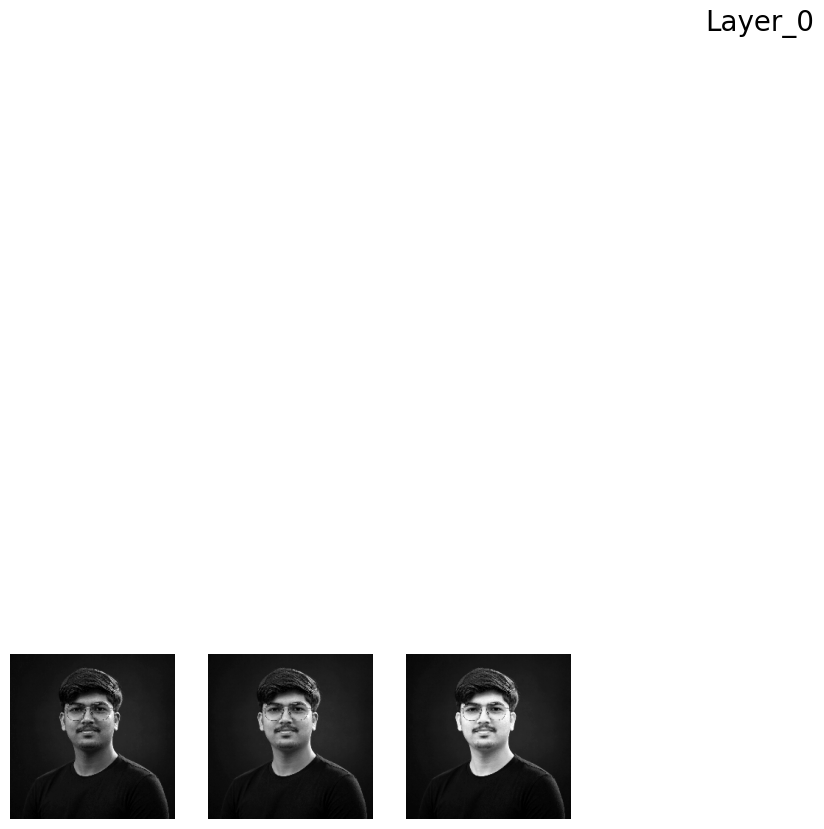

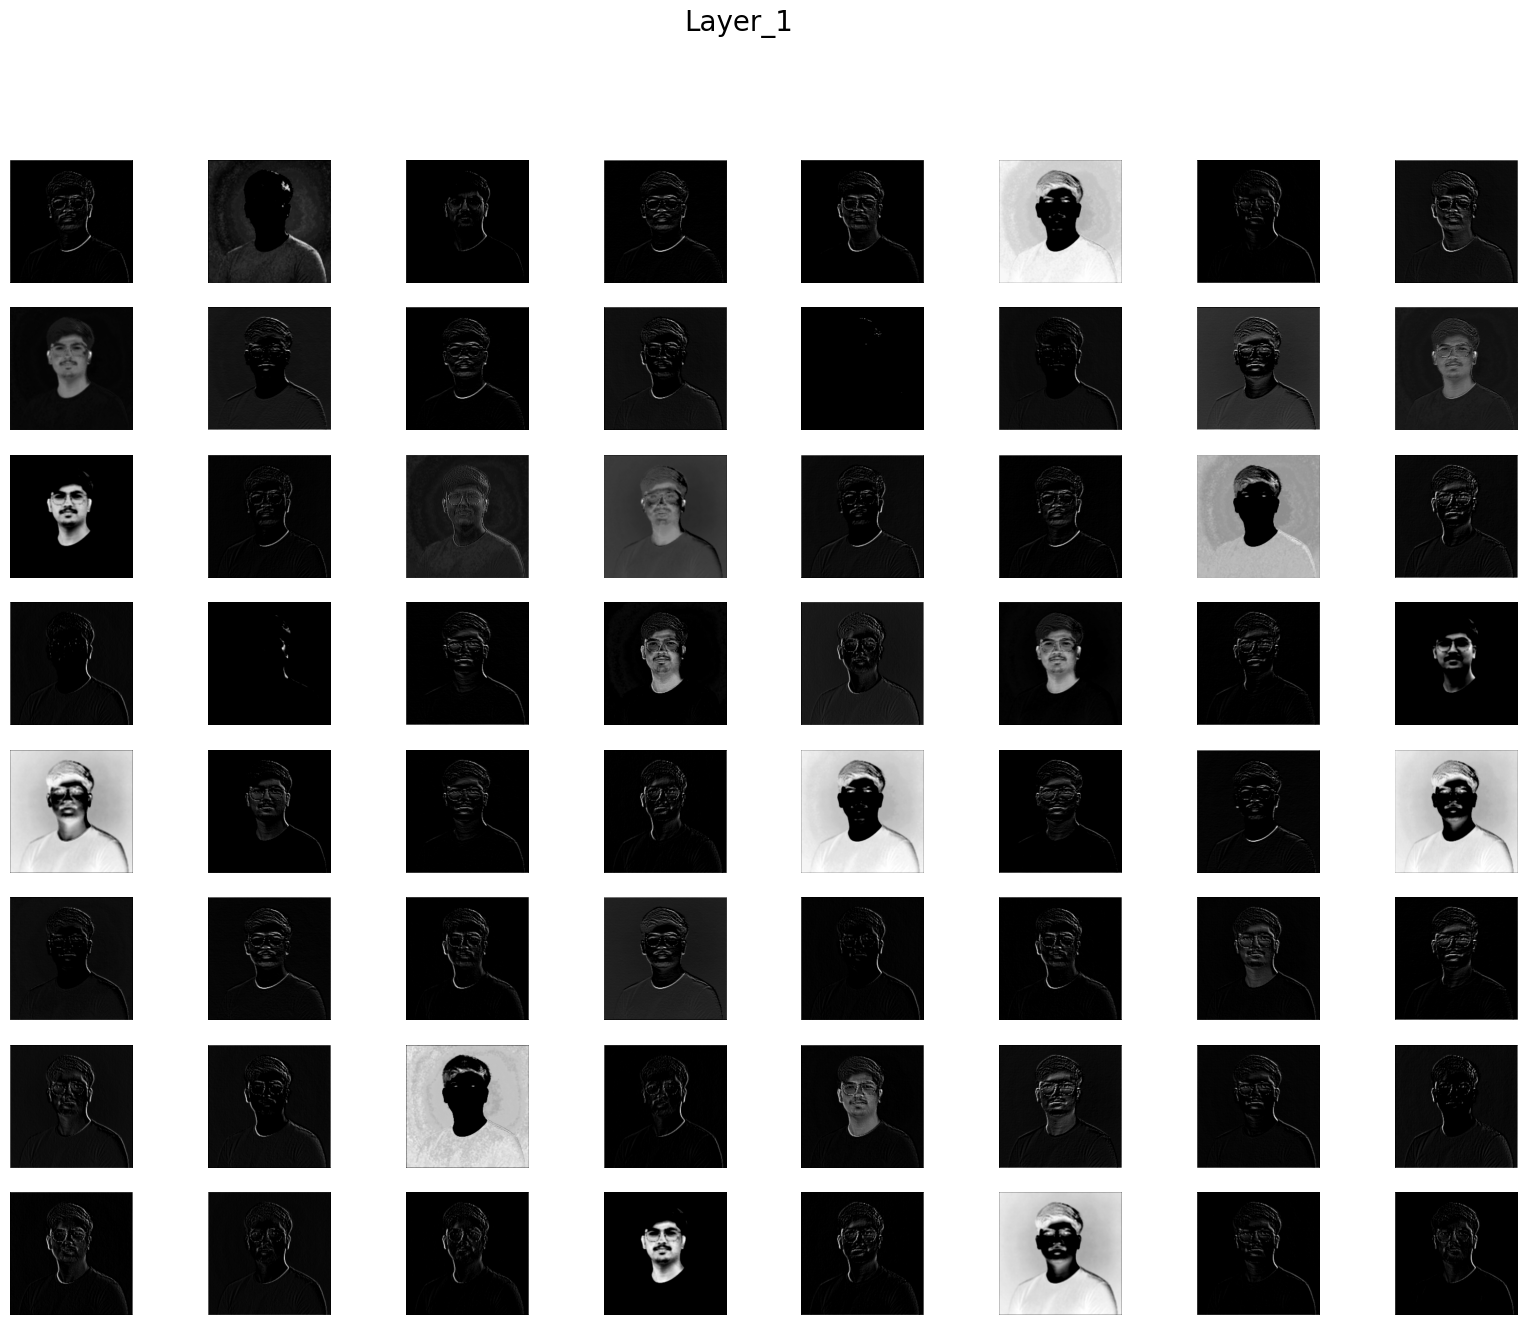

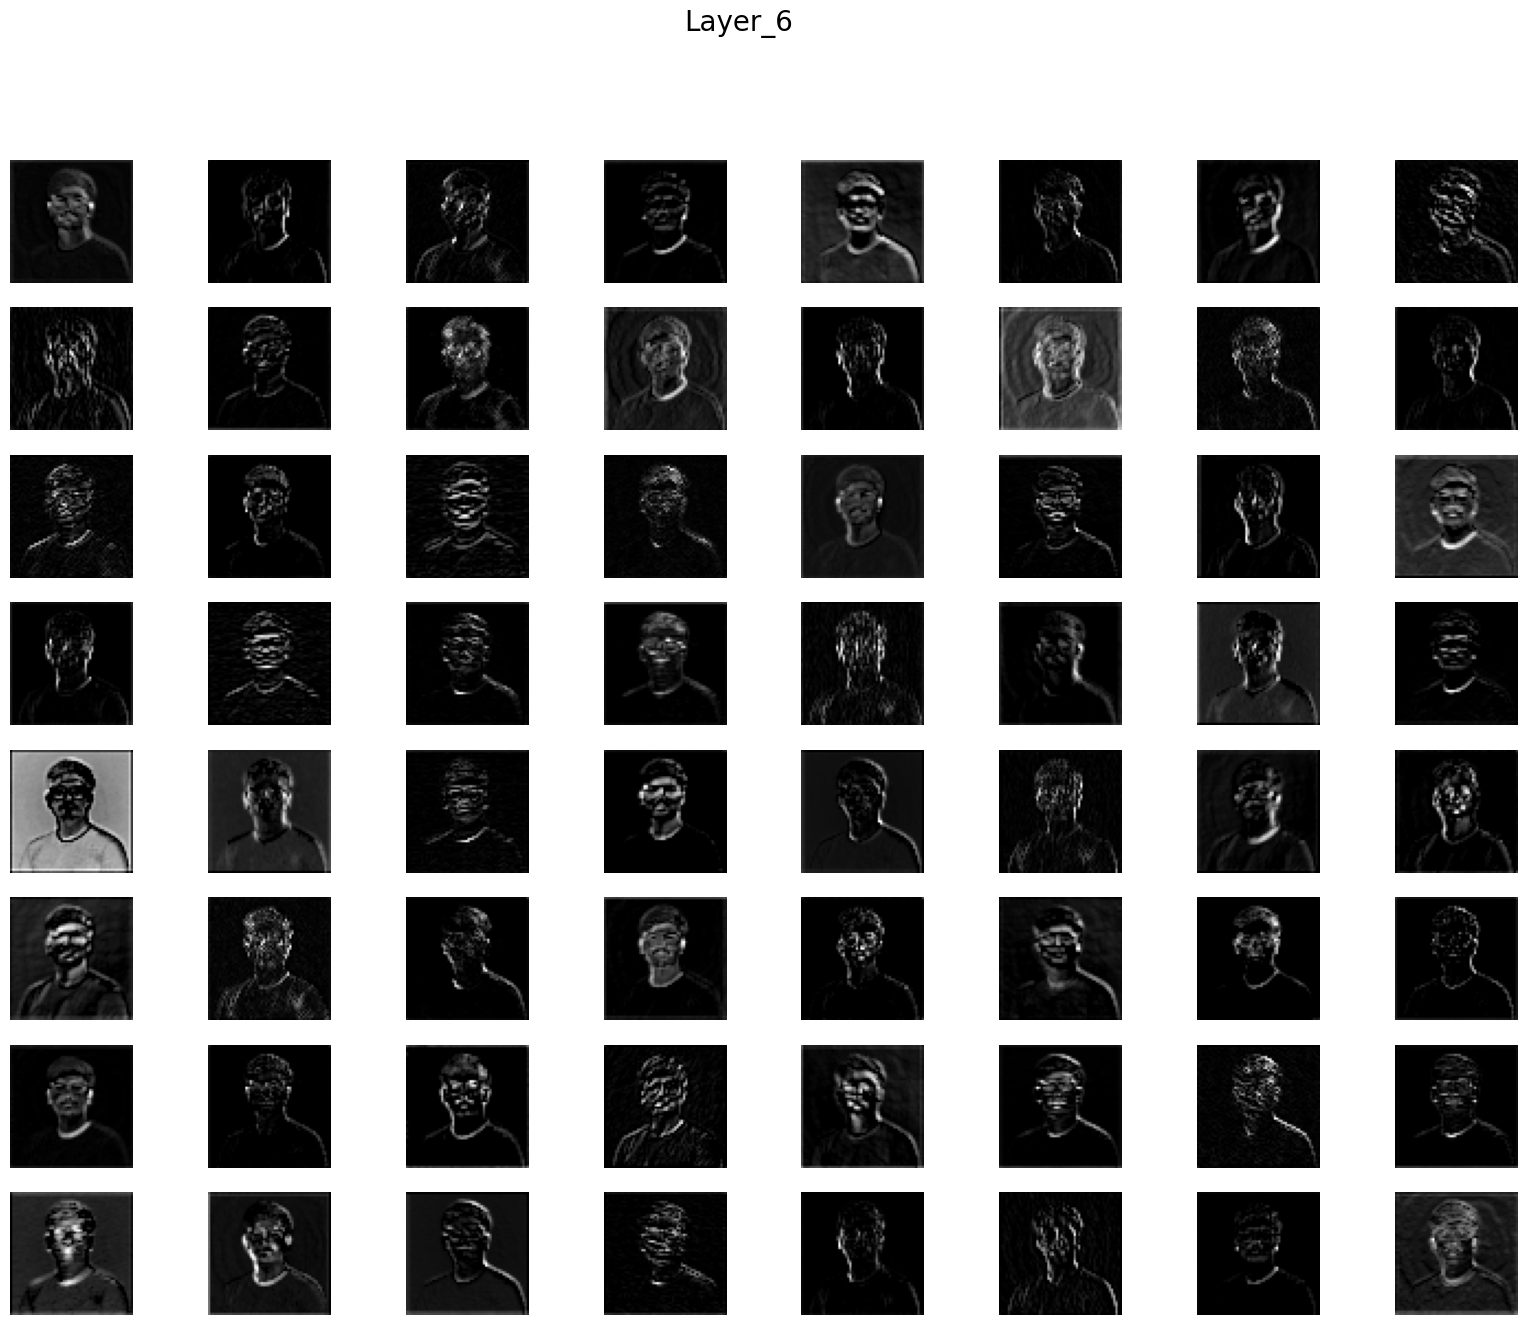

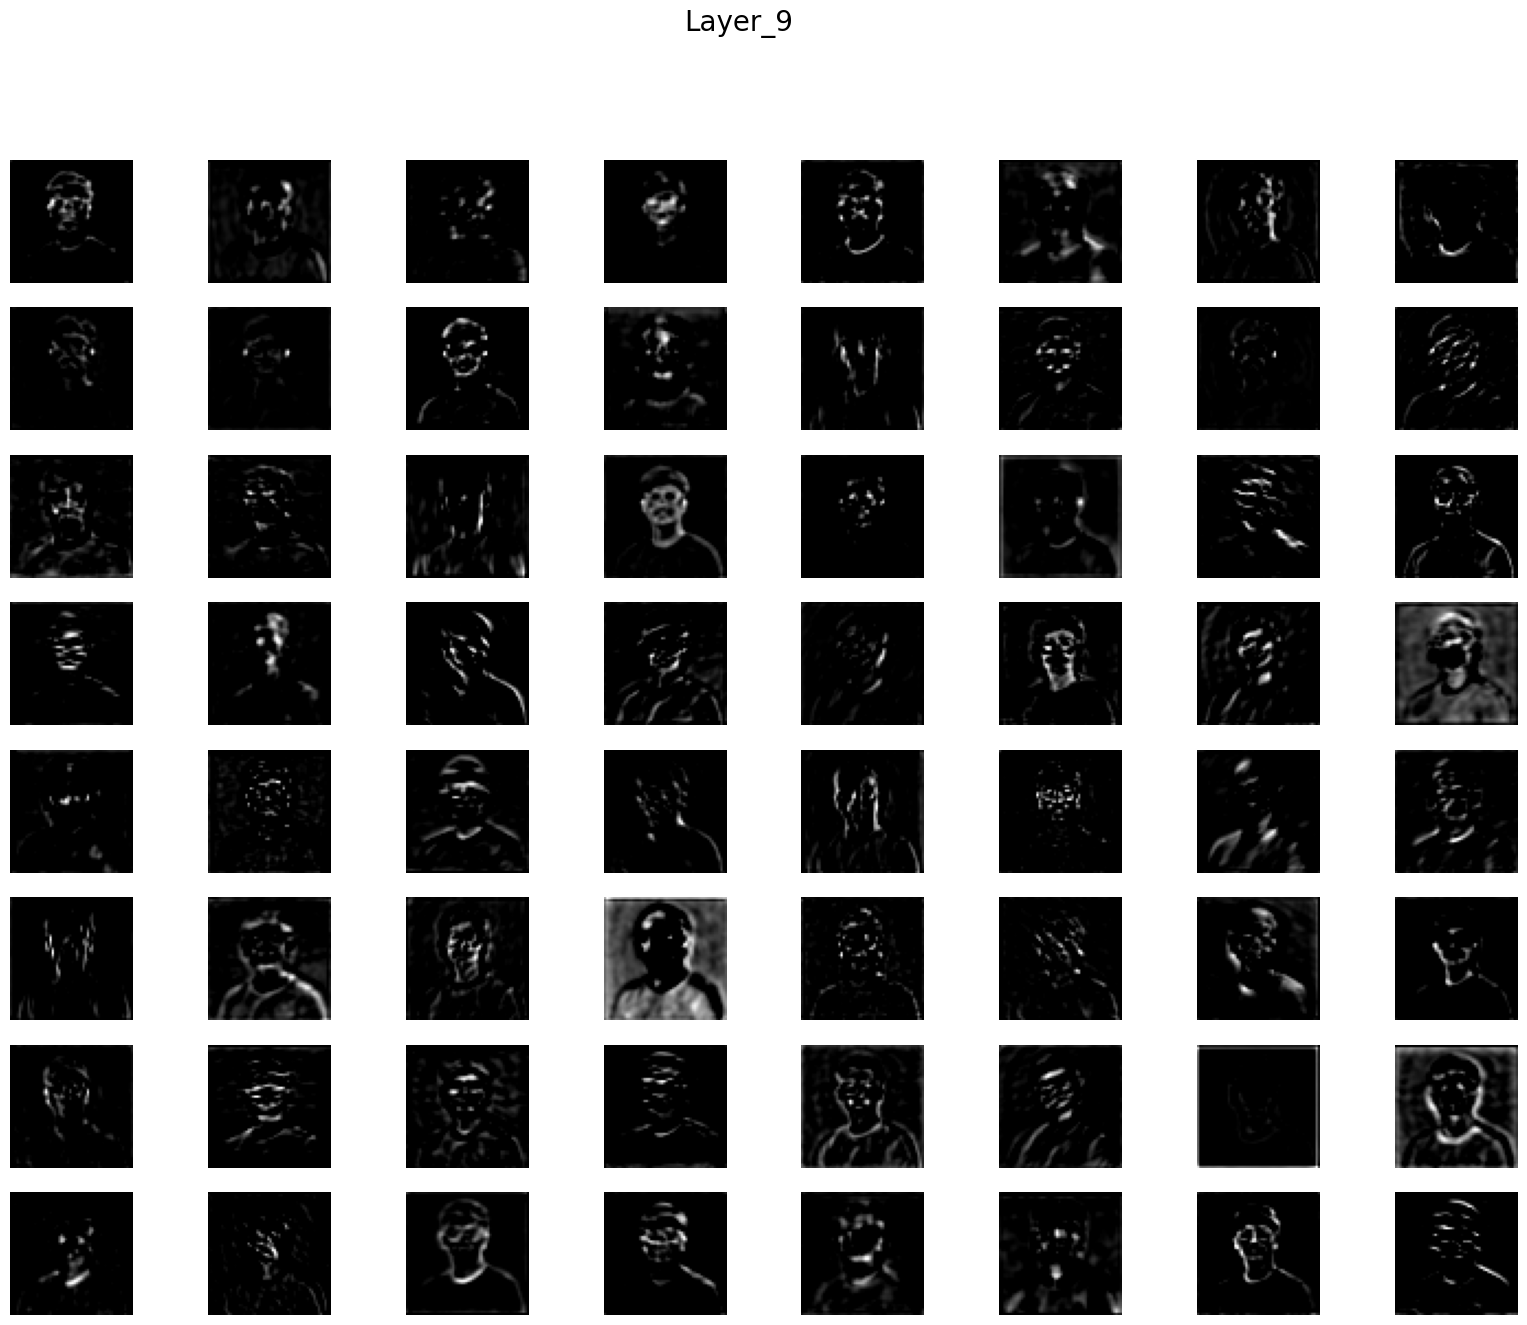

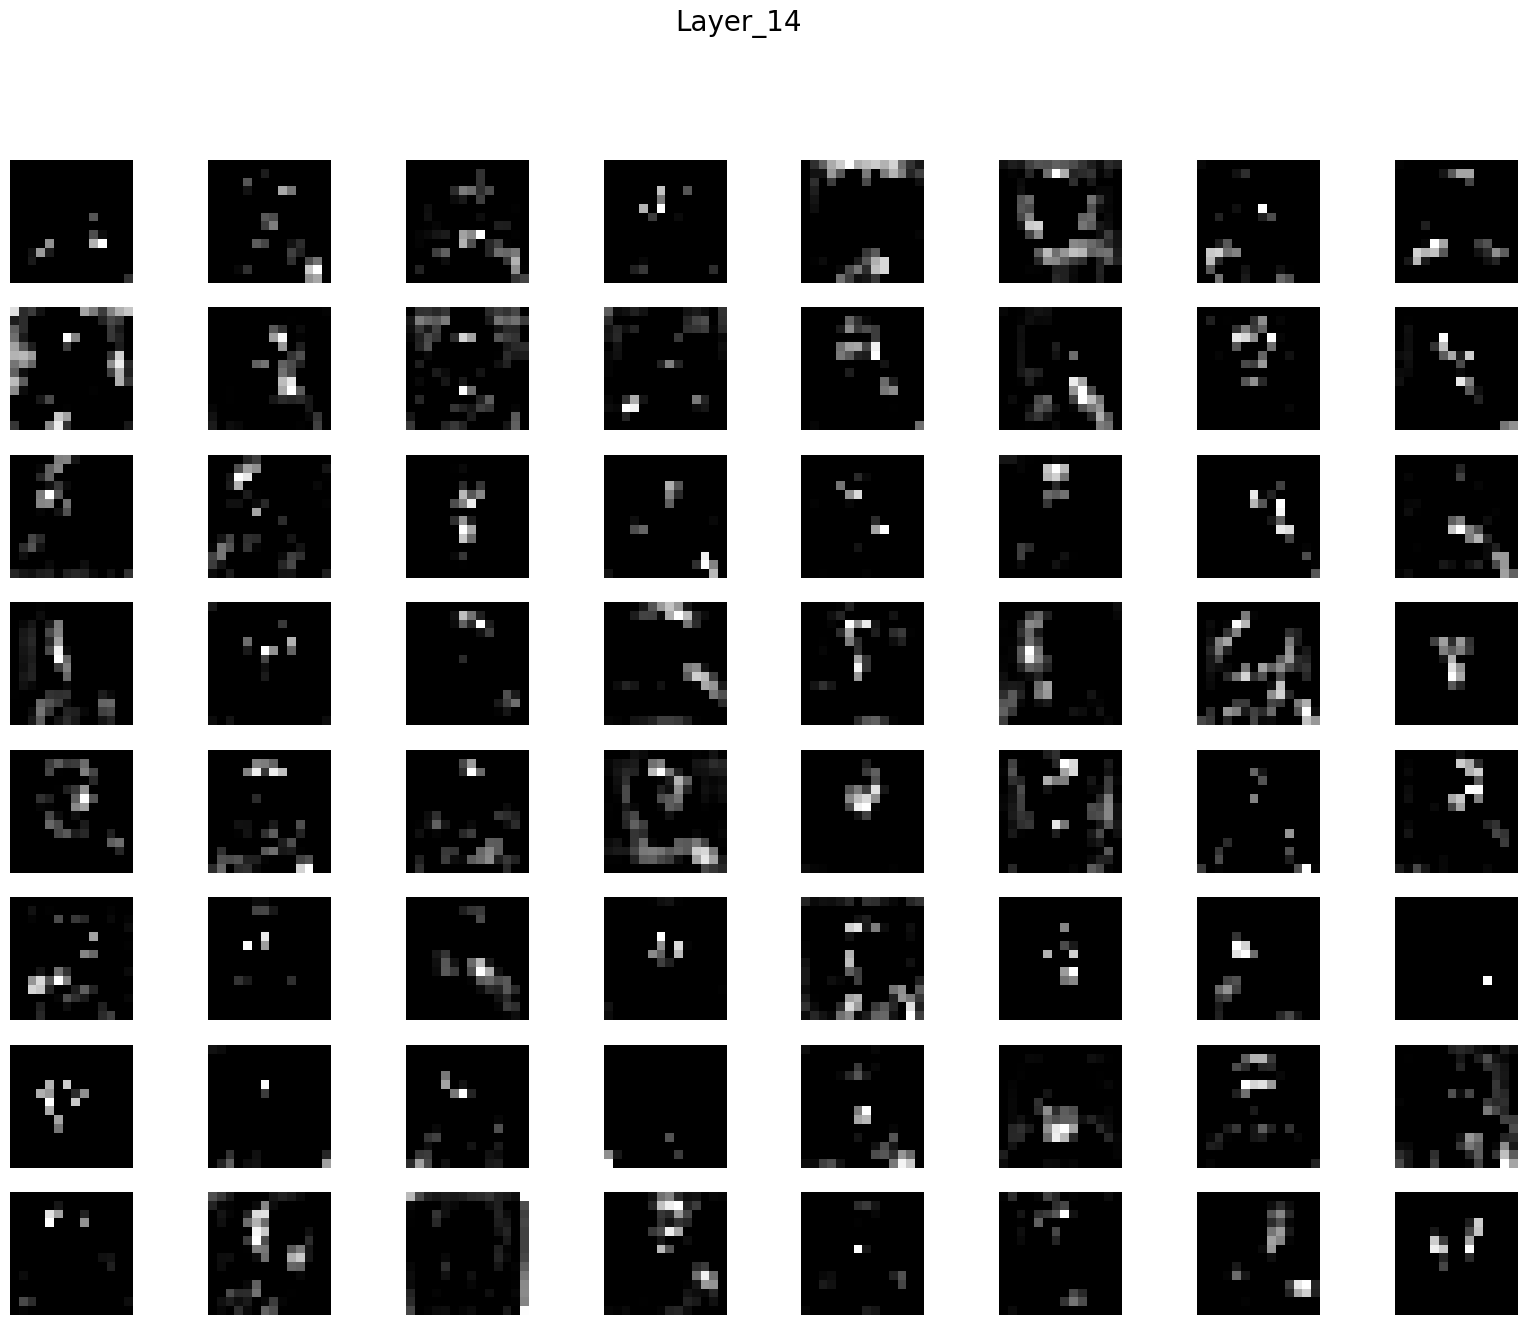

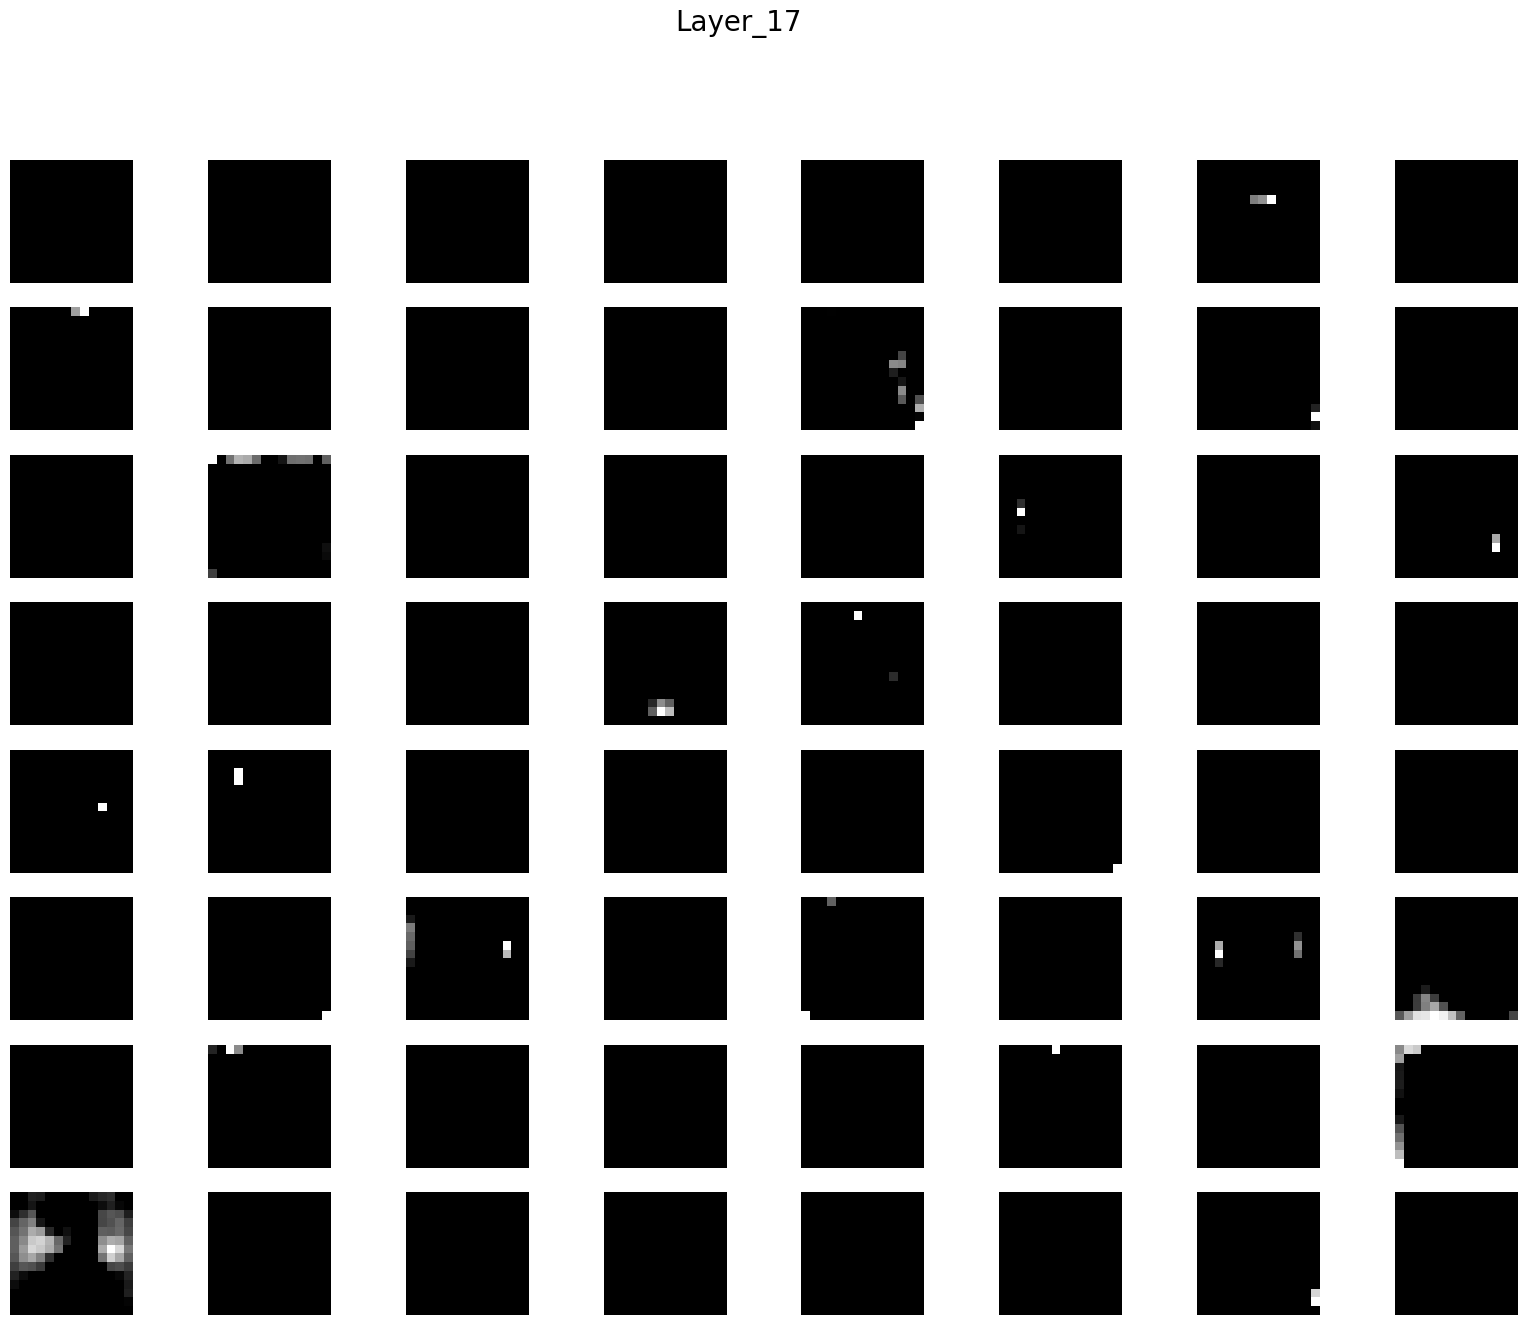

In [39]:
feature_map = model3.predict(image)

for layer_idx, fmap in zip(layer_index, feature_map):
    fig = plt.figure(figsize=(20,15))
    fig.suptitle(f"Layer_{layer_idx}" , fontsize=20)

    num_channels_to_plot = min(fmap.shape[3], 64) # Plot up to 64 channels or whatever available

    rows = int(np.ceil(num_channels_to_plot / 8.0))
    cols = 8

    for channel_idx in range(num_channels_to_plot):
        plt.subplot(rows, cols, channel_idx + 1) # subplot uses 1-based indexing for the plot number
        plt.imshow(fmap[0, :, :, channel_idx], cmap='gray')
        plt.axis('off') # To remove axes ticks and labels for cleaner plots

    plt.show()